## Remove ending behaviour


In [7]:
import pickle
# Load data
dataset_index = 5
data= pickle.load(open(f'mapped_data/data_mapped_{dataset_index}.pkl', "rb"))

In [27]:
# number of frames
data['frame'].nunique()

1821

In [28]:
# Remove the last n frames
n = 100
data = data[data['frame'] < data['frame'].max() - n]

# Save the data
data.to_pickle(f'cleaned_data/data_{dataset_index}.pkl')

Visualize cleaned data

In [35]:
import pickle
# Load data
dataset_index = 5
data= pickle.load(open(f'cleaned_data/data_{dataset_index}.pkl', "rb"))

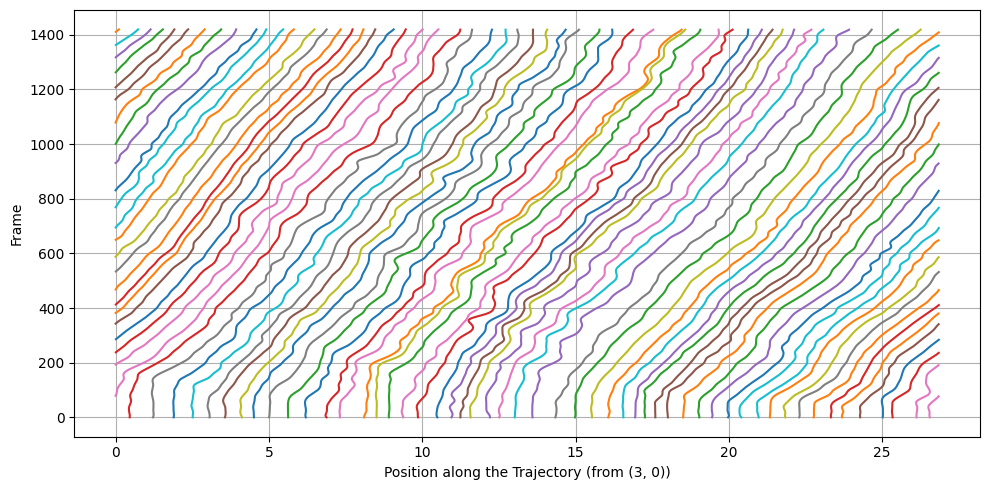

In [36]:
from matplotlib import pyplot as plt
import numpy as np
import os

# Reset position to 0 at the starting point (3, 0)
def reset_laps(person_position):
    lap_positions = []
    for index in range(len(person_position)):
        lap_positions.append(person_position[index])
        if index < len(person_position) -1 and (person_position[index] > person_position[index + 1] + 20 or person_position[index] < person_position[index + 1] - 20):
            lap_positions.append(np.nan)
    return lap_positions

# Plot position along the trajectory vs. frame
plt.figure(figsize=(10, 5))
for person_id, person_data in data.groupby('id'):
    position_list = reset_laps(person_data['position'].tolist())
    
    new_frame_list = list(range(len(position_list)))
    plt.plot(position_list, new_frame_list, label=f'Person {person_id}')

# plt.title(f'Dataset {dataset_index} 1D Trajectory: Position along the Trajectory vs. Frame')
plt.xlabel('Position along the Trajectory (from (3, 0))')
plt.ylabel('Frame')
plt.grid(True)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small', title="Person ID")
plt.tight_layout()

# save_dir = os.path.join(os.getcwd(), "plots/cleaned_trajectories")
# save_path = os.path.join(save_dir, f"trajectory_{dataset_index}.png")
# plt.savefig(save_path, dpi=300) 

plt.show()

# ODE

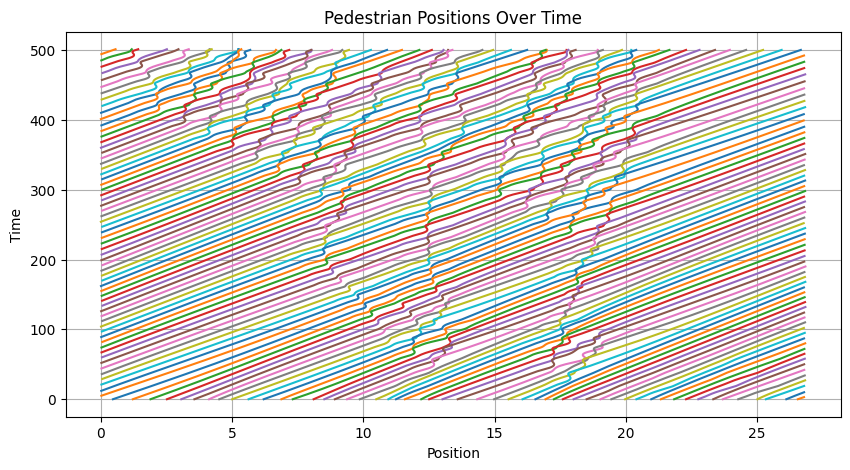

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

r = 3                      # Radius of the semicircles
l_straight = 4             # Length of the straight sections
circumference = 2*np.pi*r + l_straight * 2       # Given total circumference of the track

# Define the ODE system for pedestrian movement
def pedestrian_ode(t, l, c, s):
    n = len(l)  # Number of pedestrians
    dl_dt = np.zeros(n)
    
    for i in range(n): 
        if i == n - 1:
            gap = l[0] - (l[i] - circumference)
        else:
            gap = l[i + 1] - l[i]
        if gap > s: 
            dl_dt[i] = c[i] * (1 - s / gap)
        else:
            dl_dt[i] = 0  # If too close, pedestrian stops
    
    return dl_dt

# Initialize parameters
num_pedestrians = data['id'].nunique()
mean_speed = 1.3
std_dev_speed = 0.2
# c_values = np.random.normal(mean_speed, std_dev_speed, num_pedestrians)  # Random walking speeds normally distributed
# c_values = np.clip(c_values, 0.5, 3.0)
# s_value = 0.4  # Safety distance

c_values = []
for pedestrian in range(len(data['id'].unique())):
    c_values.append(0.09873866)

s_value = 0.1567424




# Initial positions 
initial_positions = data.groupby('id')['position'].first().values
initial_positions = np.sort(initial_positions)
# initial_positions = np.linspace(0, circumference, num_pedestrians)

# Time span for simulation
t_span = (0, 500)  # 500 frames
t_eval = np.linspace(0, 500, 500)  # Generate 500 frame steps

# Solve the ivp 
sol = solve_ivp(pedestrian_ode, t_span, initial_positions, args=(c_values, s_value), t_eval=t_eval)
positions_over_time = sol.y

positions_over_time = positions_over_time % circumference

# Plot pedestrian positions over time
plt.figure(figsize=(10, 5))
for i in range(num_pedestrians):

    position_list = reset_laps(positions_over_time[i, :].tolist())
    
    new_frame_list = list(range(len(position_list)))
    plt.plot(position_list, new_frame_list, label=f'Person {i+1}')

plt.title('Pedestrian Positions Over Time')
plt.ylabel('Time')
plt.xlabel('Position')
plt.grid(True)
plt.show()

# TODO: plot the data to the corridor to show a movie (Done)
# Normal distribution for s and c (Done)
# Compute loss function and argmin
# Train neural network NN(l_i+1 - l_i) 